# 04 · External market evidence: ordinal salary-band model & storytelling decomposition
**Team DSA · NEXUS DELTA · Build for Bharat 2.0 Round 2**  
Run top-to-bottom (Colab: Runtime → Run all). Notebooks 01→06 share files in `out/`.

In [1]:
import os, json, re, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
SEED = 42
np.random.seed(SEED)
# ---- Colab: upload the 4 organiser files to /content (left sidebar) or mount Drive and change DATA_DIR ----
DATA_DIR = "."
os.makedirs("figs", exist_ok=True); os.makedirs("out", exist_ok=True)
RES = "out/results.json"
def save_res(key, val):
    r = json.load(open(RES)) if os.path.exists(RES) else {}
    r[key] = val
    json.dump(r, open(RES, "w"), indent=1, default=float)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})
C = {"navy": "#12355b", "teal": "#1b998b", "amber": "#e09f3e", "red": "#c8553d", "grey": "#8d99ae"}

## 1. External market evidence — ordinal logistic regression on six salary bands
Target = `salary_ord` (0–5). Odds ratio OR = exp(β): >1 means a posting with the capability is more likely to sit in a *higher* salary band, holding controls fixed. **Association, not causation.**

In [2]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
a = pd.read_csv("out/analytics_clean.csv")
FL = ["big_data","maths_stats","coding","ai_ml","story"]
NAMES = {"big_data":"Big data","maths_stats":"Maths & statistics","coding":"Coding","ai_ml":"AI & ML","story":"Dashboards & storytelling"}
def design(df, suffix, spec, flags):
    X = df[[f"{f}_{suffix}" for f in flags]].astype(float).copy(); X.columns = flags
    if spec >= 2: X["exp_min"] = df.exp_min/5.0
    if spec >= 3: X = X.join(pd.get_dummies(df.seniority, prefix="sen", drop_first=False).drop(columns="sen_mid").astype(float))
    if spec >= 4: X = X.join(pd.get_dummies(df.loc_tier, prefix="loc").drop(columns="loc_Tier1").astype(float))
    if spec >= 5:
        X["exp_span"] = df.exp_span/5.0; X["jobtype_missing"] = df.jobtype_missing.astype(float); X["trunc_skills"] = df.trunc_skills.astype(float)
        X = X.join(pd.get_dummies(df.role_family, prefix="role").drop(columns="role_other").astype(float))
    return X
def fit_or(df, suffix, spec, flags=FL):
    X = design(df, suffix, spec, flags); y = df.salary_ord.values
    m = OrderedModel(y, X.values, distr="logit").fit(method="bfgs", maxiter=800, disp=False)
    k = len(flags); ci = m.conf_int()[:k]
    return {f: dict(OR=float(np.exp(m.params[i])), lo=float(np.exp(ci[i,0])), hi=float(np.exp(ci[i,1])), p=float(m.pvalues[i])) for i, f in enumerate(flags)}, m, len(df)
P = a[a.is_ds_p]; W = a[a.is_ds_w]
SPECS = {"S1 flags only":(P,"p",1), "S2 +experience":(P,"p",2), "S3 +seniority":(P,"p",3), "S4 +location":(P,"p",4), "S5 +all controls (primary tax.)":(P,"p",5), "S6 all controls (wide tax. & population)":(W,"w",5)}
out = {}; t0 = time.time()
for nme, (df, sfx, sp) in SPECS.items():
    out[nme], _, n = fit_or(df, sfx, sp); print(f"{nme:44s} n={n}")
print(f"({time.time()-t0:.0f}s)\n")
tab = pd.DataFrame({s: {NAMES[f]: f"{v[f]['OR']:.2f} [{v[f]['lo']:.2f},{v[f]['hi']:.2f}]" for f in FL} for s, v in out.items()})
print(tab.to_string())
prem = {f: int(sum(out[s][f]["lo"] > 1 for s in out)) for f in FL}; disc = {f: int(sum(out[s][f]["hi"] < 1 for s in out)) for f in FL}
print("\nspecs with significant PREMIUM (CI>1):", {NAMES[f]: v for f, v in prem.items()})
print("specs with significant DISCOUNT (CI<1):", {NAMES[f]: v for f, v in disc.items()})
save_res("market_or", out); save_res("market_premium_specs", prem); save_res("market_discount_specs", disc)

S1 flags only                                n=6097


S2 +experience                               n=6097


S3 +seniority                                n=6097


S4 +location                                 n=6097


S5 +all controls (primary tax.)              n=6097


S6 all controls (wide tax. & population)     n=10338
(10s)

                              S1 flags only    S2 +experience     S3 +seniority      S4 +location S5 +all controls (primary tax.) S6 all controls (wide tax. & population)
Big data                   1.77 [1.51,2.07]  1.16 [0.99,1.37]  1.16 [0.98,1.36]  1.16 [0.98,1.37]                1.09 [0.89,1.34]                         1.15 [0.97,1.36]
Maths & statistics         1.60 [1.42,1.80]  1.41 [1.24,1.60]  1.31 [1.16,1.49]  1.30 [1.14,1.48]                1.27 [1.11,1.45]                         1.42 [1.28,1.57]
Coding                     1.54 [1.38,1.71]  1.52 [1.36,1.71]  1.53 [1.37,1.71]  1.53 [1.36,1.71]                1.52 [1.35,1.70]                         1.55 [1.42,1.70]
AI & ML                    1.93 [1.69,2.21]  2.08 [1.80,2.40]  2.13 [1.85,2.46]  2.13 [1.84,2.45]                1.38 [1.08,1.75]                         1.25 [1.04,1.50]
Dashboards & storytelling  0.69 [0.61,0.78]  0.75 [0.66,0.85]  0.74 [0.65,0.84]  0.74

## 2. Decompose the storytelling conflict and test sensitivity (promotional-title rows, taxonomy)

In [3]:
# storytelling family -> visualisation-tools vs MIS/reporting-only
a["viz_only_p"] = a.viz_p; a["mis_only_p"] = a.mis_only_p
dec, _, n = fit_or(P, "p", 5, flags=["big_data","maths_stats","coding","ai_ml","viz","mis_only"])
print("Storytelling decomposition (primary taxonomy, S5 controls):")
for f in ["viz","mis_only"]: print(f"  {f:9s} OR={dec[f]['OR']:.2f} [{dec[f]['lo']:.2f}, {dec[f]['hi']:.2f}]  p={dec[f]['p']:.4f}")
# sensitivity: drop promotional-style titles
Pn = P[~P.spam_title]; sens, _, n2 = fit_or(Pn, "p", 5)
shift = {f: float(sens[f]["OR"] - out["S5 +all controls (primary tax.)"][f]["OR"]) for f in FL}
print(f"\nExcluding {int(P.spam_title.sum())} promotional-title rows (n={n2}): max |ΔOR| = {max(abs(v) for v in shift.values()):.3f}")
print({NAMES[f]: round(v,3) for f, v in shift.items()})
# senior-title-only subset check (is the storytelling discount a seniority artefact?)
Pj = P[P.seniority.isin(["junior","mid","senior"])]; jr, _, n3 = fit_or(Pj, "p", 5)
print(f"\nJunior/mid/senior titles only (n={n3}): " + ", ".join(f"{NAMES[f]} {jr[f]['OR']:.2f}" for f in FL))
save_res("story_decomp", dict(viz=dec["viz"], mis_only=dec["mis_only"], n=n)); save_res("spam_shift", shift)
save_res("market_junior_subset", jr)

Storytelling decomposition (primary taxonomy, S5 controls):
  viz       OR=0.98 [0.80, 1.20]  p=0.8381
  mis_only  OR=0.66 [0.57, 0.77]  p=0.0000



Excluding 586 promotional-title rows (n=5511): max |ΔOR| = 0.066
{'Big data': 0.011, 'Maths & statistics': 0.006, 'Coding': -0.025, 'AI & ML': -0.066, 'Dashboards & storytelling': 0.015}



Junior/mid/senior titles only (n=4816): Big data 1.17, Maths & statistics 1.37, Coding 1.62, AI & ML 1.61, Dashboards & storytelling 0.74


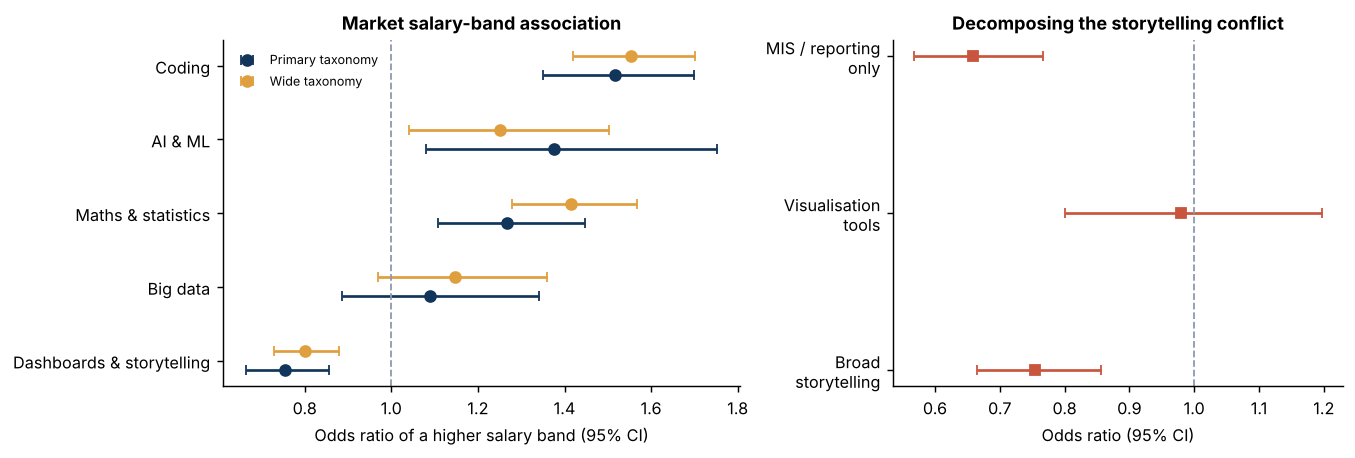

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6), gridspec_kw={"width_ratios":[1.15,1]})
order = sorted(FL, key=lambda f: out["S5 +all controls (primary tax.)"][f]["OR"])
for j, (s, col, off) in enumerate([("S5 +all controls (primary tax.)", C["navy"], -0.13), ("S6 all controls (wide tax. & population)", C["amber"], 0.13)]):
    r = [out[s][f] for f in order]; yy = np.arange(len(order)) + off
    ax[0].errorbar([x["OR"] for x in r], yy, xerr=[[x["OR"]-x["lo"] for x in r], [x["hi"]-x["OR"] for x in r]], fmt="o", color=col, capsize=3, label=["Primary taxonomy","Wide taxonomy"][j])
ax[0].axvline(1, color=C["grey"], ls="--", lw=1); ax[0].set_yticks(range(len(order))); ax[0].set_yticklabels([NAMES[f] for f in order]); ax[0].legend(frameon=False, fontsize=7)
ax[0].set_xlabel("Odds ratio of a higher salary band (95% CI)"); ax[0].set_title("Market salary-band association")
dd = [("Broad\nstorytelling", out["S5 +all controls (primary tax.)"]["story"]), ("Visualisation\ntools", dec["viz"]), ("MIS / reporting\nonly", dec["mis_only"])]
ax[1].errorbar([d[1]["OR"] for d in dd], range(3), xerr=[[d[1]["OR"]-d[1]["lo"] for d in dd], [d[1]["hi"]-d[1]["OR"] for d in dd]], fmt="s", color=C["red"], capsize=3)
ax[1].axvline(1, color=C["grey"], ls="--", lw=1); ax[1].set_yticks(range(3)); ax[1].set_yticklabels([d[0] for d in dd]); ax[1].set_title("Decomposing the storytelling conflict"); ax[1].set_xlabel("Odds ratio (95% CI)")
plt.tight_layout(); plt.savefig("figs/fig04_market.png", bbox_inches="tight"); plt.show()

## 3. Bharat lens: where are the data/analytics jobs, and do capabilities and pay differ by location tier?

share of ALL cleaned postings by tier (%): {'Tier1': 89.8, 'Tier2_3': 9.2, 'International': 1.0}
               postings  mean_band  pct_band_ge_10LPA  ai_ml  coding  maths  viz   mis
loc_tier                                                                              
International        63        3.7               79.4    4.8     7.9    9.5  4.8   9.5
Tier1              5627        2.4               51.0   15.0    30.6   17.8  5.6  13.1
Tier2_3             407        1.5               29.0    6.9    16.0    9.8  3.7  11.3


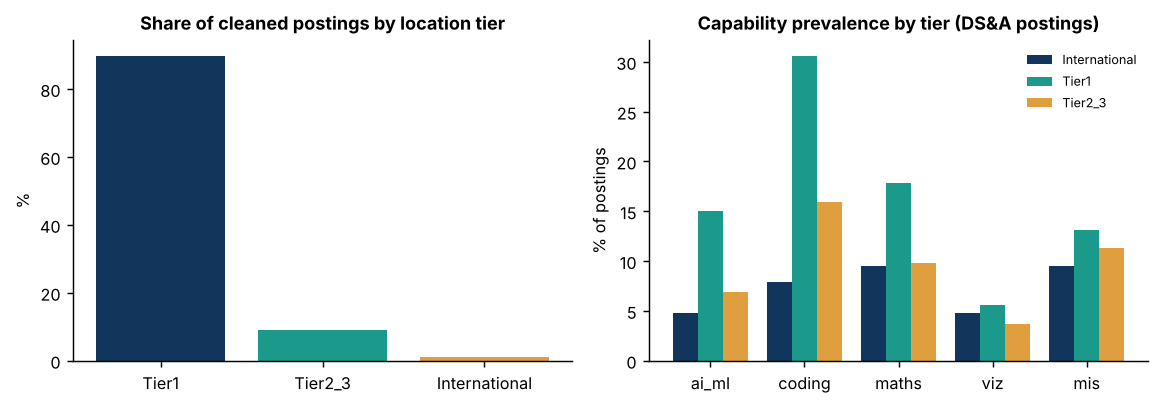

In [5]:
tier_all = a.loc_tier.value_counts(normalize=True)*100
bh = a[a.is_ds_p].groupby("loc_tier").agg(postings=("salary_ord","size"), mean_band=("salary_ord","mean"), pct_band_ge_10LPA=("salary_ord", lambda s: (s>=3).mean()*100),
        ai_ml=("ai_ml_p","mean"), coding=("coding_p","mean"), maths=("maths_stats_p","mean"), viz=("viz_p","mean"), mis=("mis_p","mean"))
for c in ["ai_ml","coding","maths","viz","mis"]: bh[c] = bh[c]*100
print("share of ALL cleaned postings by tier (%):", tier_all.round(1).to_dict()); print(bh.round(1).to_string())
save_res("bharat", dict(tier_share=tier_all.round(2).to_dict(), table=bh.round(2).reset_index().to_dict("records")))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(tier_all.index, tier_all.values, color=[C["navy"], C["teal"], C["amber"]]); ax[0].set_title("Share of cleaned postings by location tier"); ax[0].set_ylabel("%")
bh[["ai_ml","coding","maths","viz","mis"]].T.plot.bar(ax=ax[1], color=[C["navy"], C["teal"], C["amber"]], width=.8); ax[1].set_title("Capability prevalence by tier (DS&A postings)"); ax[1].set_ylabel("% of postings"); ax[1].legend(frameon=False, fontsize=7); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig("figs/fig07_bharat.png", bbox_inches="tight"); plt.show()